# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

Foi identificada a necessidade de alterar o tipo da coluna weight (peso), que estava no formato object, para o tipo float, a fim de permitir análises numéricas adequadas. Durante a verificação inicial, constatou-se que a base não apresentava valores nulos. Entretanto, duas colunas chamaram atenção devido à distribuição dos dados e possível presença de outliers: height (altura) e weight (peso). Foi realizado um tratamento na coluna de altura, removendo registros de indivíduos com menos de 1 metro e mais de 2 metros, por serem considerados valores fora do padrão esperado. Após esse ajuste, a análise da coluna de peso indicou que, apesar de alguns valores parecerem incomuns à primeira vista, eles são coerentes e podem representar casos reais, não sendo necessário realizar tratamento adicional nessa variável.

In [3]:
# seu código aqui
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [22]:
base['weight'].unique()


array([ 62. ,  85. ,  64. ,  82. ,  56. ,  67. ,  93. ,  95. ,  71. ,
        68. ,  80. ,  60. ,  78. , 112. ,  75. ,  52. ,  83. ,  69. ,
        90. ,  45. ,  65. ,  59. ,  66. ,  74. , 105. ,  73. ,  55. ,
        70. ,  72. ,  63. ,  50. , 107. ,  84. ,  77. ,  79. ,  76. ,
        58. , 115. ,  97. ,  53. ,  57. ,  49. , 110. ,  94. ,  92. ,
        87. , 103. ,  88. ,  99. , 100. ,  61. ,  48. ,  54. ,  51. ,
        47. ,  91. , 104. ,  81. ,  98. , 108. ,  89. , 101. ,  86. ,
        65.5, 142. ,  96. ,  44. ,  41. , 169. , 116. , 200. ,  64.8,
       120. , 117. , 125. , 106. , 114. , 113. , 129. , 124. ,  42. ,
       123. , 111. , 102. , 109. ,  46. , 139. , 150. , 138. , 131. ,
        43. ,  83.6, 134. , 106.5, 121. ,  40. , 141. , 119. , 126. ,
       177. , 165. , 122. ,  62.3, 118. ,  89.5, 132. , 155. , 130. ,
       159. ,  84.6, 140. ,  82.3,  30. ,  67.9, 127. ,  67.5,  74.3,
       149. , 180. , 128. ,  60.2,  64.5,  58.7,  90.5,  37. ,  80.8,
       166. , 161. ,

In [9]:
base['weight'] = base['weight'].str.replace(',', '.').astype(float)

print (base.dtypes)

age                 int64
gender              int64
height              int64
weight            float64
cholesterol         int64
gluc                int64
smoke               int64
alco                int64
active              int64
cardio_disease      int64
dtype: object


In [10]:
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
base['cholesterol'].unique()

array([1, 3, 2])

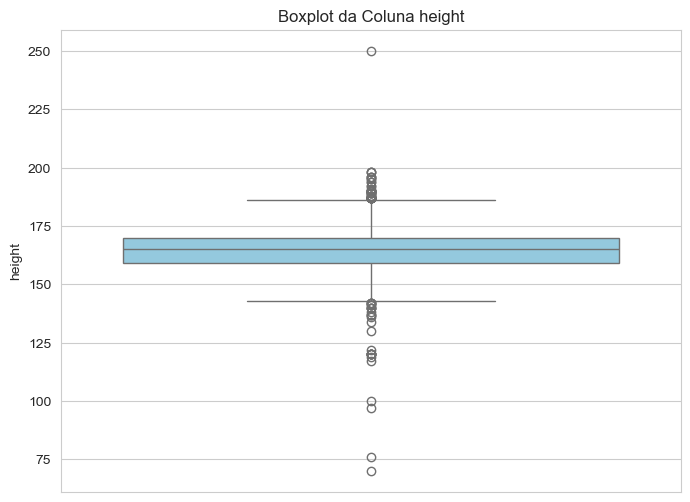

In [13]:
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=base, y='height', color='skyblue')
plt.title('Boxplot da Coluna height')
plt.ylabel('height')
plt.show()

In [14]:
base[base['height'] < 100]

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
224,60,2,76,55.0,1,1,0,0,1,0
7598,40,2,70,72.0,1,1,0,0,1,0
8171,48,2,97,170.0,1,1,1,0,1,1


In [16]:
base[base['height'] > 199]

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
6486,58,1,250,86.0,3,1,0,0,1,1


In [23]:
base = base[(base['height'] >= 100) & (base['height'] <= 200)]
base

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62.0,1,1,0,0,1,0
1,55,1,156,85.0,3,1,0,0,1,1
2,52,1,165,64.0,3,1,0,0,0,1
3,48,2,169,82.0,1,1,0,0,1,1
4,48,1,156,56.0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,56,1,166,65.0,1,1,0,0,0,0
9996,50,1,160,93.0,2,1,0,0,1,1
9997,40,1,158,66.0,2,2,0,0,1,0
9998,50,1,168,70.0,3,1,0,0,1,1


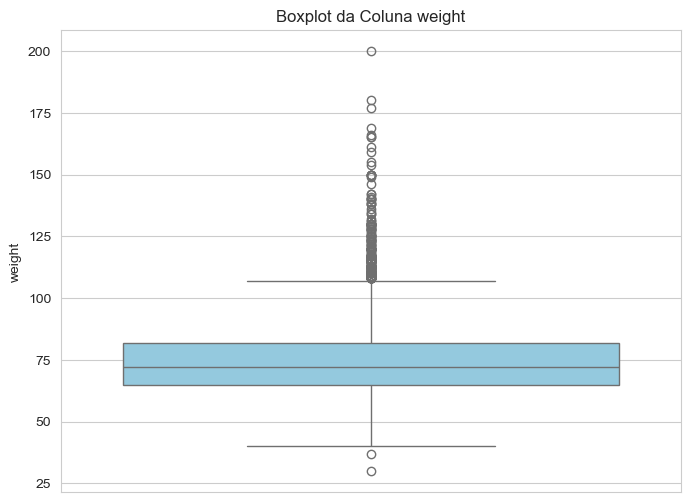

In [24]:
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=base, y='weight', color='skyblue')
plt.title('Boxplot da Coluna weight')
plt.ylabel('weight')
plt.show()

In [20]:
base[base['weight'] < 40]

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
3752,42,1,120,30.0,1,1,0,0,1,0
5794,48,1,151,37.0,1,1,0,0,1,0


In [30]:
base[base['weight'] > 190]

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
435,46,1,186,200.0,1,1,0,0,0,0


# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


# seu código aqui
A partir dos 56 anos, observa-se uma maior frequência de pessoas com problemas cardíacos, sendo essa condição mais comum entre os homens. Por outro lado, os dados indicam que as mulheres apresentam maior frequência de consumo de álcool e tabagismo em comparação aos homens. Além disso, pessoas com problemas cardíacos tendem a praticar mais atividade física.

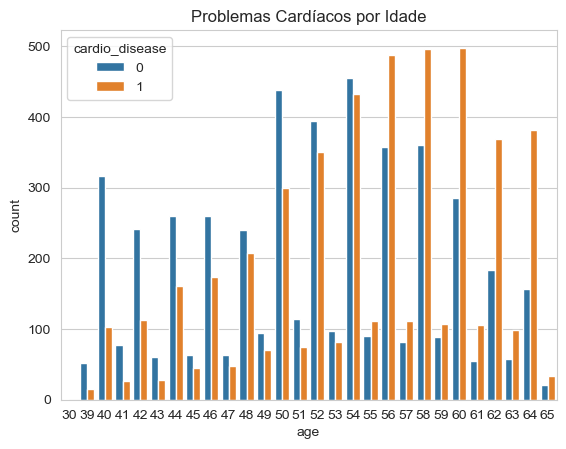

In [49]:
sns.countplot(x='age', hue='cardio_disease', data=base)
plt.title('Problemas Cardíacos por Idade')
plt.show()

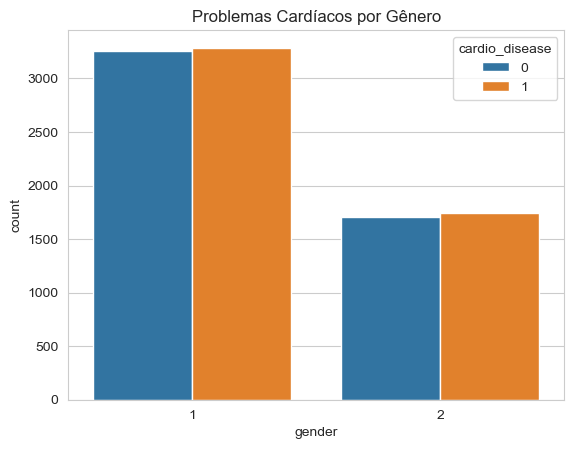

In [38]:
sns.countplot(x='gender', hue='cardio_disease', data=base)
plt.title('Problemas Cardíacos por Gênero')
plt.show()

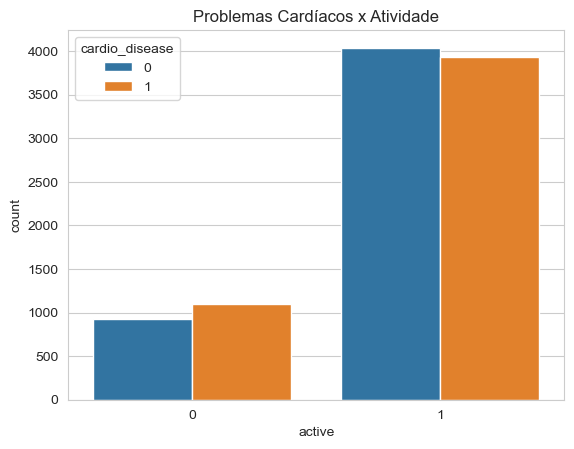

In [56]:
sns.countplot(x='active', hue='cardio_disease', data=base)
plt.title('Problemas Cardíacos x Atividade Física')
plt.show()

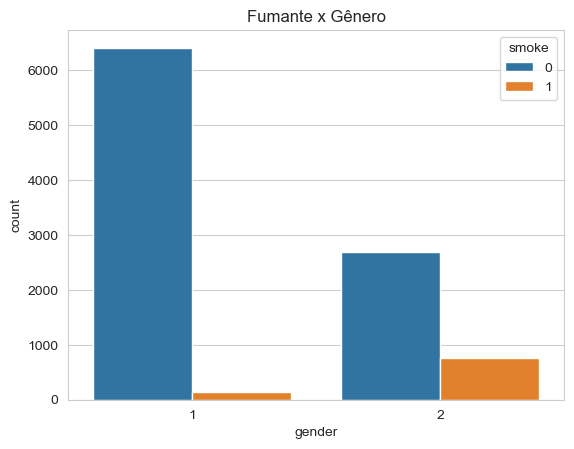

In [52]:
sns.countplot(x='gender', hue='smoke', data=base)
plt.title('Fumante x Gênero')
plt.show()

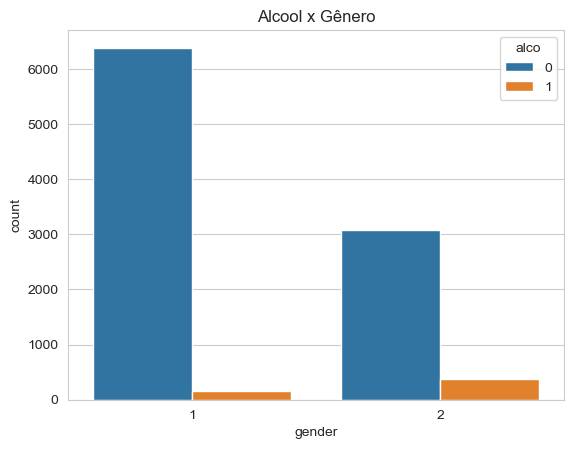

In [53]:
sns.countplot(x='gender', hue='alco', data=base)
plt.title('Alcool x Gênero')
plt.show()

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



A análise da matriz de correlação indicou que as variáveis apresentam, de modo geral, baixa correlação com a variável principal. A maior associação foi observada com idade (0,24), seguida por colesterol (0,22) e peso (0,18), o que sugere ausência de relações lineares fortes com a variável alvo. Por outro lado, ao analisar a relação entre as variáveis independentes, verificou-se que a maior correlação ocorreu entre gender (gênero) e height (altura), com valor de 0,51, caracterizando uma correlação moderada entre essas variáveis.

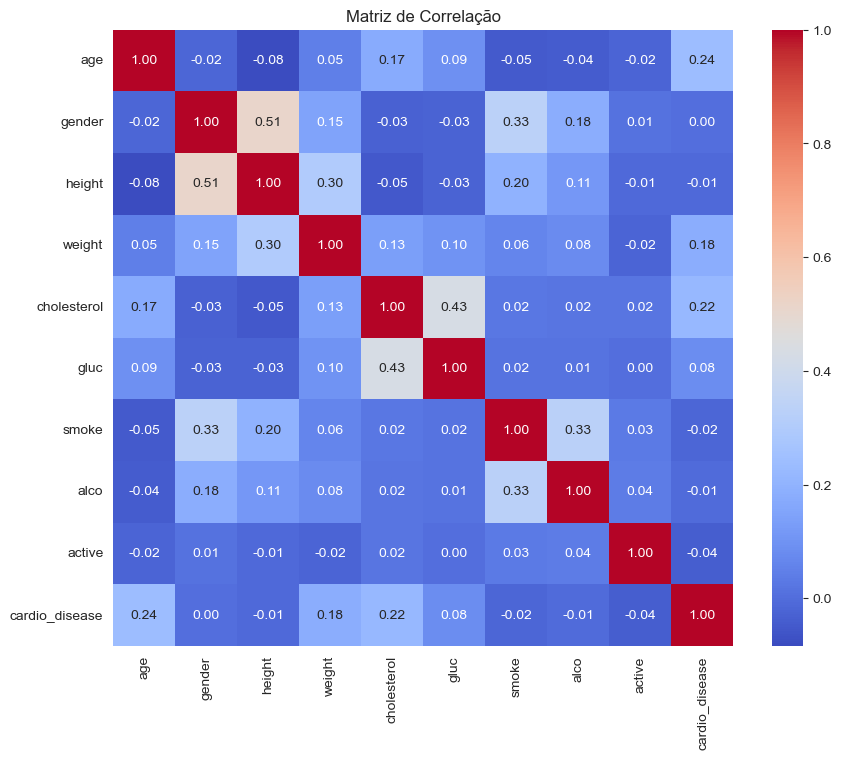

In [31]:
# seu código aqui

correlation_matrix = base.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

B) Sim, a base deve ser padronizada, pois possui variáveis em diferentes escalas, o que pode influenciar negativamente o desempenho de modelos sensíveis à magnitude dos dados. A padronização garante que todas as variáveis contribuam de forma equilibrada para o modelo.


In [57]:
# seu código aqui
# Separando em X (variáveis de entrada) e Y (variável de saída)
X = base.drop('cardio_disease', axis=1) 
Y = base['cardio_disease'] 

In [60]:
# Separar em base de treino e teste (usando 80% para treino e 20% para teste)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [61]:
# Inicializar StandardScaler
sc = StandardScaler()

# Ajustando e transformando os dados de treino
X_train = sc.fit_transform(X_train)

# Transformando os dados de teste usando os parâmetros aprendidos dos dados de treino
X_test = sc.transform(X_test)

In [64]:
base['cardio_disease'].value_counts()

cardio_disease
1    5029
0    4967
Name: count, dtype: int64

In [66]:
# Balancear os dados de treinamento usando SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

In [69]:
X_train_balanced

array([[ 0.40218898, -0.72582941,  1.46807586, ...,  3.18622383,
        -0.2413128 ,  0.50796054],
       [-1.36592413,  1.37773419,  0.7160669 , ..., -0.31385115,
        -0.2413128 ,  0.50796054],
       [-2.10263792,  1.37773419,  0.7160669 , ..., -0.31385115,
        -0.2413128 ,  0.50796054],
       ...,
       [-0.8099256 , -0.72582941,  0.2832868 , ..., -0.31385115,
        -0.2413128 , -1.96865684],
       [-0.18718206, -0.72582941, -0.58175358, ..., -0.31385115,
        -0.2413128 ,  0.50796054],
       [-0.06553093,  1.37773419,  0.61258626, ..., -0.31385115,
        -0.2413128 ,  0.50796054]], shape=(8090, 9))

In [70]:
Y_train_balanced

0       0
1       1
2       1
3       0
4       1
       ..
8085    0
8086    0
8087    0
8088    0
8089    0
Name: cardio_disease, Length: 8090, dtype: int64

In [71]:
X_test

array([[ 0.69687449, -0.72582941,  0.08939276, ..., -0.31385115,
        -0.2413128 , -1.96865684],
       [ 0.40218898, -0.72582941,  0.34006242, ..., -0.31385115,
        -0.2413128 ,  0.50796054],
       [-1.07123861,  1.37773419,  1.34274104, ..., -0.31385115,
        -0.2413128 ,  0.50796054],
       ...,
       [ 0.10750346, -0.72582941, -0.53728138, ..., -0.31385115,
        -0.2413128 ,  0.50796054],
       [-0.18718206,  1.37773419,  1.21740621, ...,  3.18622383,
        -0.2413128 ,  0.50796054],
       [-1.51326688, -0.72582941, -0.03594207, ..., -0.31385115,
        -0.2413128 ,  0.50796054]], shape=(2000, 9))

In [72]:
Y_test

1079    1
4337    0
8970    0
5457    0
2408    1
       ..
1096    0
3112    1
4193    1
1562    0
1671    1
Name: cardio_disease, Length: 2000, dtype: int64

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

# seu código aqui
D) O modelo, no conjunto de treino, apresentou acurácia de 64%, precisão de 64%, recall de 61% e F1-score de 62%. Esses resultados indicam um desempenho moderado, sugerindo que o modelo conseguiu aprender parte dos padrões dos dados, porém ainda com limitações na identificação correta dos casos positivos.

In [73]:
#Iniciando o treinamento
logistic_carro = LogisticRegression(random_state = 0)

In [74]:
logistic_carro.fit(X_train_balanced, Y_train_balanced)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [76]:
logistic_carro.intercept_

array([0.01626587])

In [77]:
logistic_carro.coef_

array([[ 4.26269475e-01,  3.89945959e-02, -1.04627409e-01,
         3.72480920e-01,  4.04209801e-01, -8.03125576e-02,
        -5.89550611e-02,  2.53119204e-04, -8.29324553e-02]])

In [78]:
previsoes = logistic_carro.predict(X_train_balanced)

In [79]:
relatorio = classification_report(Y_train_balanced, previsoes)
print("Relatório de Classificação:")
print(relatorio)


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.63      0.67      0.65      4045
           1       0.64      0.61      0.62      4045

    accuracy                           0.64      8090
   macro avg       0.64      0.64      0.64      8090
weighted avg       0.64      0.64      0.64      8090



# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

# seu código aqui
No conjunto de teste, o modelo apresentou acurácia de 65%, precisão de 65%, recall de 62% e F1-score de 63%. Esses resultados são bastante próximos aos obtidos no treino, indicando que o modelo possui boa capacidade de generalização, sem sinais evidentes de overfitting.
O modelo apresentou um valor de ROC AUC de 0,65, indicando uma capacidade de discriminação moderada entre as classes.O resultado sugere que o modelo consegue diferenciar casos positivos e negativos melhor do que o acaso (0,5), porém ainda está distante de um desempenho considerado forte (acima de 0,8).

In [80]:
Y_pred_test = logistic_carro.predict(X_test)

In [81]:
relatorio = classification_report(Y_test, Y_pred_test)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.65      0.68      0.66      1016
           1       0.65      0.62      0.63       984

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000



In [82]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_test)
# Calcular a AUC
roc_auc = roc_auc_score(Y_test, Y_pred_test)
print("AUC: {:.2f}".format(roc_auc))

AUC: 0.65


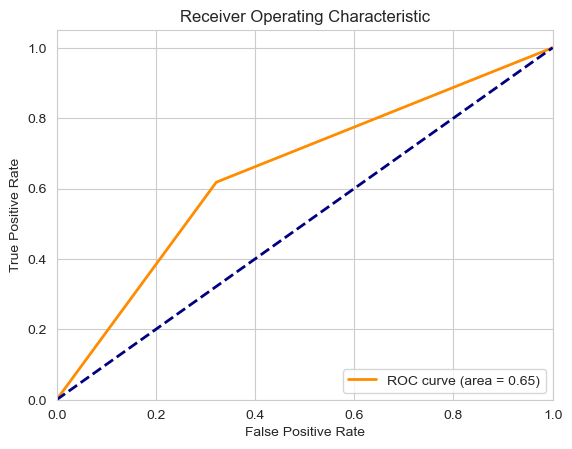

In [83]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



# seu código aqui
A) A Regresão Logistica é um modelo de aprendizado supervisionado usado para prever a problabilidade de um evento acontecer. Ela transformar a probabilidade em 0 e 1, indicando a chance de pertencer a uma determinada classe.
B) Porque apesar de ele calcular a probabilidade do evento de acontecer, o objetivo final dele é classificar o resultado em categorias.
C) Ambas são modelos de aprendizado supervisionado, possuem coeficientes que indicam a importância de cada variável, utilizam técnicas de otimização para ajustar seus parâmetros e se baseiam em uma combinação linear das variáveis.
